<h1> Geometric Operations and Other Mathematical Tools with Pillow</h1>


Estimated time needed: **40** minutes


<h2> Spatial Operations in Image Processing</h2>


Spatial operations use  pixels in a neighborhood to determine the present pixel value. Some applications include filtering and sharpening. They are used in many steps in computer vision, such as segmentation, and are a key building block in Artificial Intelligence algorithms.


- Linear Filtering
    - Filtering Noise
    - Gaussian Blur
    - Image Sharpening
- Edges
- Median


* * *


Download the images for the lab


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png   

--2026-03-06 16:42:08--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7243 (7.1K) [image/jpeg]
Saving to: ‘cameraman.jpeg.1’

cameraman.jpeg.1    100%[===================>]   7.07K  --.-KB/s    in 0s      

2026-03-06 16:42:11 (1.12 GB/s) - ‘cameraman.jpeg.1’ saved [7243/7243]

--2026-03-06 16:42:11--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cl

We will import the following libraries


In [2]:
# Nhập thư viện để hiển thị hình ảnh
import matplotlib.pyplot as plt
# Nhập thư viện để tải ảnh
from PIL import Image
# Nhập thư viện để tạo kernel lọc và xử lý mảng
import numpy as np

This function will plot two images side by side 


In [3]:
# Hàm hiển thị hai ảnh cạnh nhau
def plot_image(image_1, image_2, title_1="Orignal", title_2="New Image"):
    plt.figure(figsize=(10,10))          # Tạo vùng vẽ với kích thước 10x10 inch
    plt.subplot(1, 2, 1)                 # Tạo ô con thứ nhất (1 hàng, 2 cột, ô thứ 1)
    plt.imshow(image_1)                  # Hiển thị ảnh thứ nhất
    plt.title(title_1)                    # Đặt tiêu đề cho ảnh thứ nhất
    plt.subplot(1, 2, 2)                 # Tạo ô con thứ hai (ô thứ 2)
    plt.imshow(image_2)                  # Hiển thị ảnh thứ hai
    plt.title(title_2)                    # Đặt tiêu đề cho ảnh thứ hai
    plt.show()                            # Hiển thị toàn bộ figure

Spatial operations use the neighboring pixels to determine the present pixel value 


## Linear  Filtering


Filtering involves enhancing an image, for example, removing the noise from an image. Noise can be caused by a bad camera or bad image compression. The same factors that cause noise may lead to blurry images. We can apply filters to sharpen these images. Convolution is a standard way to filter an image. The filter is called the kernel and different kernels perform different tasks. In addition, Convolution is used for many of the most advanced artificial intelligence algorithms. We simply take the dot product of the kernel and an equally-sized portion of the image. We then shift the kernel and repeat.


Consider the following image:


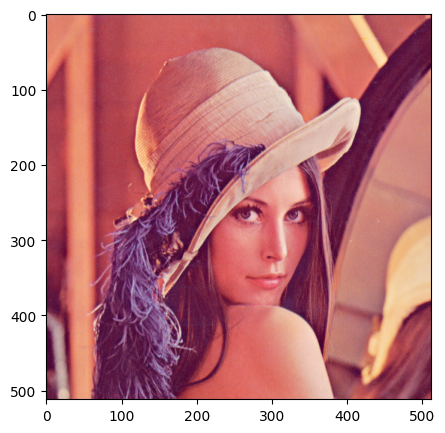

In [4]:
# Tải ảnh từ file "lenna.png"
image = Image.open("lenna.png")
# Hiển thị ảnh gốc
plt.figure(figsize=(5,5))                # Tạo figure với kích thước 5x5 inch
plt.imshow(image)                         # Hiển thị ảnh
plt.show()                                 # Hiển thị

The images we are working with are comprised of RGB values, which are values from 0 to 255. Zero means white noise, this makes the image look grainy:


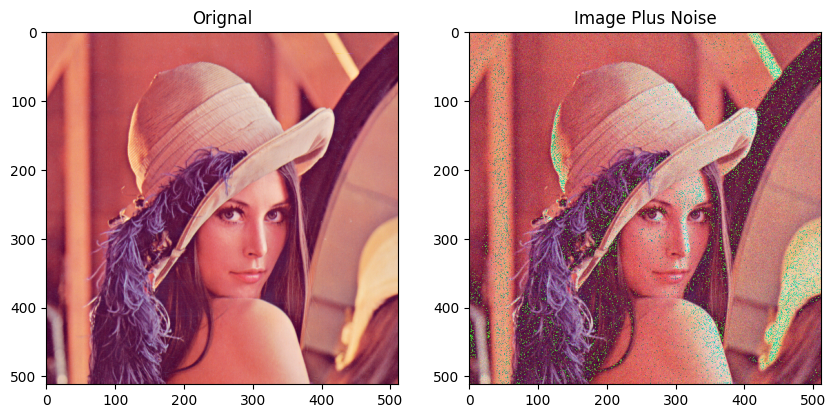

In [5]:
# Lấy kích thước ảnh (số hàng và số cột)
rows, cols = image.size
# Tạo nhiễu tuân theo phân phối chuẩn (trung bình 0, độ lệch chuẩn 15) và chuyển sang kiểu uint8 (giá trị từ 0-255)
noise = np.random.normal(0,15,(rows,cols,3)).astype(np.uint8)
# Cộng nhiễu vào ảnh gốc
noisy_image = image + noise
# Chuyển mảng numpy thành đối tượng ảnh PIL
noisy_image = Image.fromarray(noisy_image)
# Hiển thị ảnh gốc và ảnh đã thêm nhiễu
plot_image(image, noisy_image, title_1="Orignal", title_2="Image Plus Noise")

When adding noise to an image sometimes the value might be greater than 255, in this case 256, is subtracted from the value to wrap the number around keeping it between 0 and 255. For example, consider an image with an RGB value of 137 and we add noise with an RGB value of 215 to get an RGB value of 352. We then subtract 256, the total number of possible values between 0 and 255, to get a number between 0 and 255.


### Filtering Noise


To be able to create customer kernels and use predefined filters we must import the following library


In [6]:
from PIL import ImageFilter   # Nhập module lọc ảnh từ PIL

Smoothing filters average out the Pixels within a neighborhood, they are sometimes called low pass filters. For mean filtering, the  kernel simply averages out the kernels in a neighborhood.


In [7]:
# Tạo kernel (bộ lọc) kích thước 5x5, mỗi phần tử có giá trị 1/36 (bộ lọc trung bình)
kernel = np.ones((5,5))/36
# Tạo đối tượng Kernel cho PIL bằng cách cung cấp kích thước và mảng kernel được làm phẳng
kernel_filter = ImageFilter.Kernel((5,5), kernel.flatten())

The function <code>filter</code> performs a convolution between the image and the kernel on each color channel independently.


In [8]:
# Áp dụng bộ lọc lên ảnh nhiễu
image_filtered = noisy_image.filter(kernel_filter)

We can plot the image before and after the filtering. We see the noise is reduced, but the image is blurry:


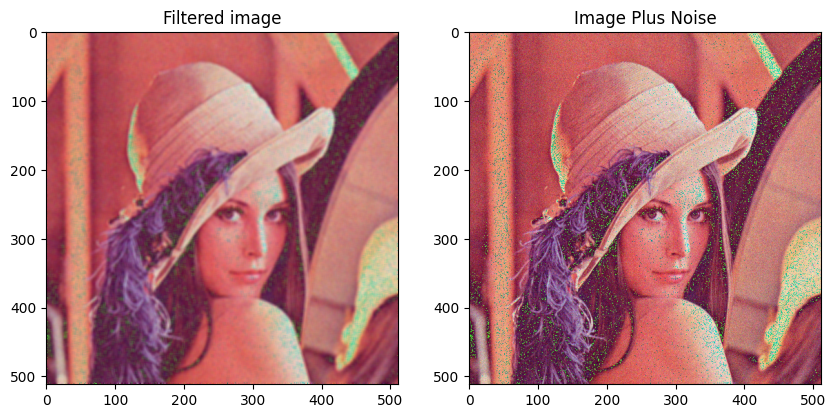

In [9]:
# Hiển thị ảnh đã lọc và ảnh nhiễu
plot_image(image_filtered, noisy_image, title_1="Filtered image", title_2="Image Plus Noise")


A smaller kernel keeps the image sharp, but filters less noise, here we try a 3x3 kernel. You can see her shoulders are sharper in this image but the green noise is brighter than the filtered image above.


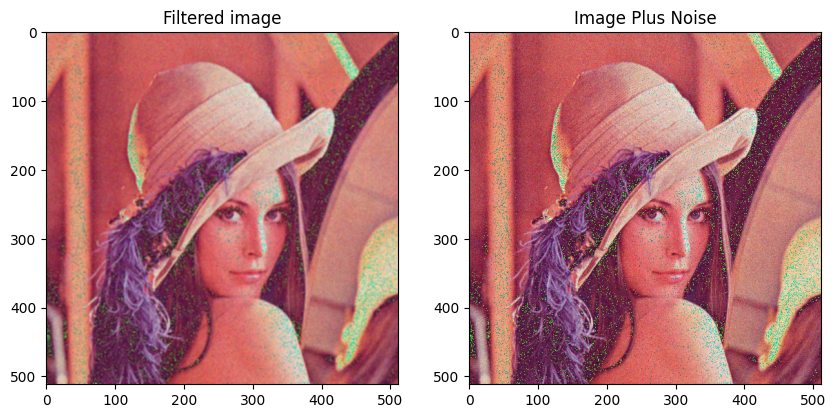

In [10]:

# Tạo kernel kích thước 3x3, mỗi phần tử 1/36
kernel = np.ones((3,3))/36
# Tạo kernel filter cho PIL
kernel_filter = ImageFilter.Kernel((3,3), kernel.flatten())
# Lọc ảnh nhiễu với kernel 3x3
image_filtered = noisy_image.filter(kernel_filter)
# Hiển thị kết quả
plot_image(image_filtered, noisy_image, title_1="Filtered image", title_2="Image Plus Noise")


### Gaussian Blur


To perform Gaussian Blur we use the `filter` function on an image using the predefined filter `ImageFilter.GaussianBlur`


Parameters

<p><code>radius</code>: blur kernel radius, default 2</p>


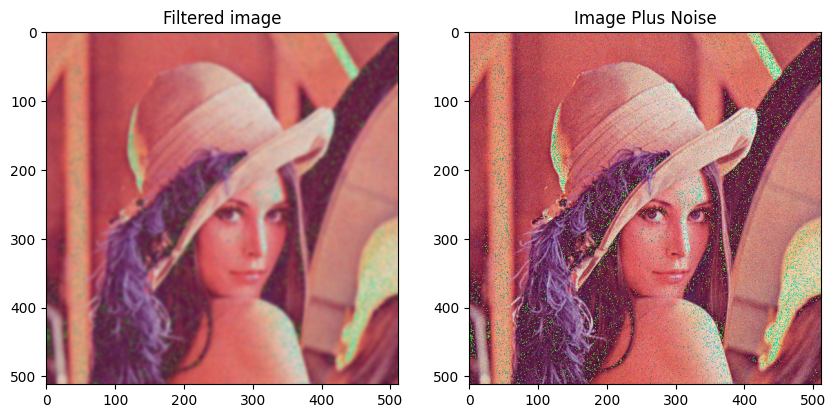

In [11]:
# Lọc ảnh nhiễu bằng bộ lọc Gaussian mặc định
image_filtered = noisy_image.filter(ImageFilter.GaussianBlur)
# Hiển thị ảnh đã lọc và ảnh nhiễu
plot_image(image_filtered, noisy_image, title_1="Filtered image", title_2="Image Plus Noise")


Lets try using a 4 by 4 kernel


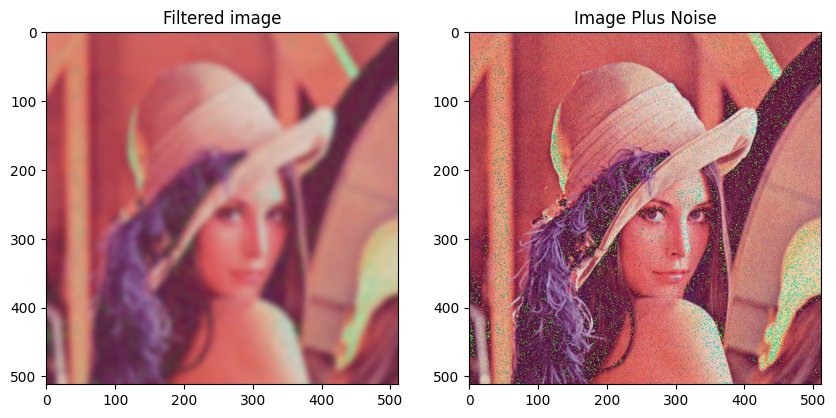

In [12]:
# Lọc ảnh nhiễu bằng Gaussian với bán kính 4 (kernel 4x4)
image_filtered = noisy_image.filter(ImageFilter.GaussianBlur(4))
plot_image(image_filtered, noisy_image, title_1="Filtered image", title_2="Image Plus Noise")


### Image Sharpening


Image Sharpening involves smoothing the image and calculating the derivatives.  We can accomplish image sharpening by applying the following Kernel.


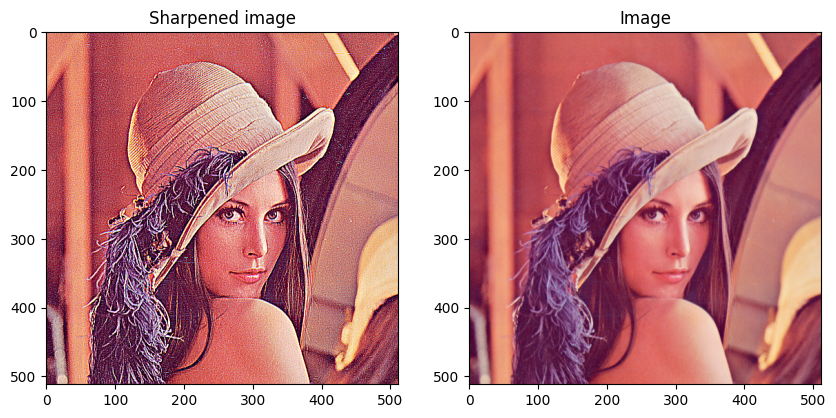

In [13]:
# Kernel làm nét ảnh thông dụng (laplacian sharpening)
kernel = np.array([[-1,-1,-1],
                   [-1, 9,-1],
                   [-1,-1,-1]])
# Tạo kernel filter từ mảng trên
kernel = ImageFilter.Kernel((3,3), kernel.flatten())
# Áp dụng bộ lọc làm nét lên ảnh gốc (không nhiễu)
sharpened = image.filter(kernel)
# Hiển thị ảnh đã làm nét và ảnh gốc
plot_image(sharpened, image, title_1="Sharpened image", title_2="Image")

We can also sharpen using a predefined filter


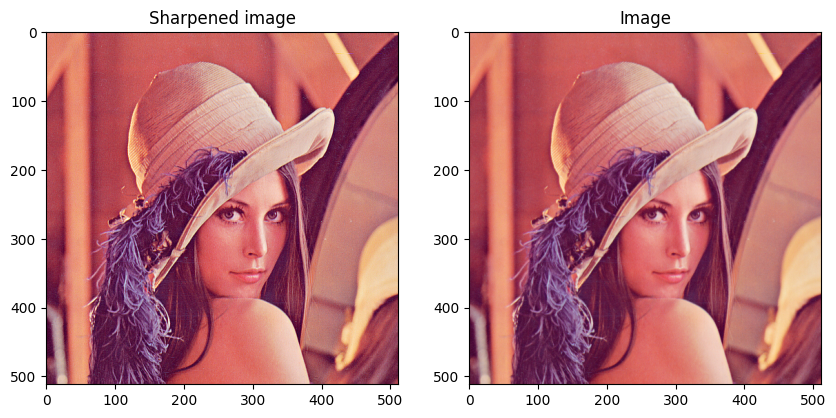

In [14]:
# Sử dụng bộ lọc làm nét có sẵn trong PIL
sharpened = image.filter(ImageFilter.SHARPEN)
# Hiển thị kết quả
plot_image(sharpened, image, title_1="Sharpened image", title_2="Image")

## Edges


Edges are where pixel intensities change. The Gradient of a function outputs the rate of change; we can approximate the gradient of a grayscale image with convolution. Consider the following image:


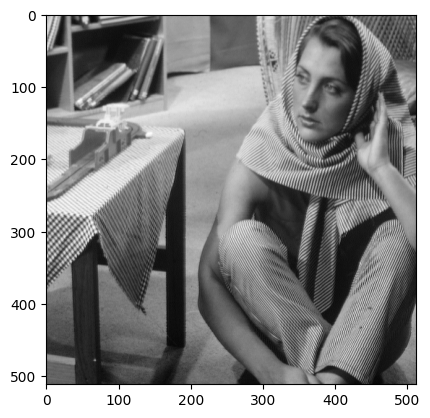

In [15]:
# Tải ảnh xám từ file 'barbara.png'
img_gray = Image.open('barbara.png')
# Hiển thị ảnh xám (dùng colormap 'gray')
plt.imshow(img_gray, cmap='gray')

We enhance the edges so they are better picked up when we use edge detection


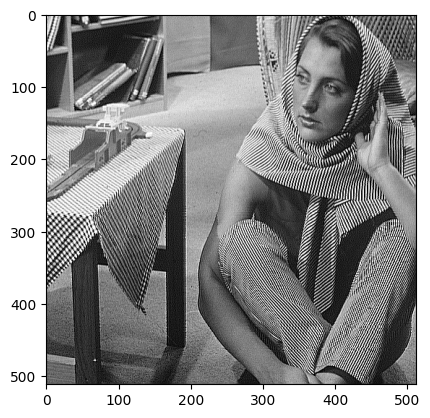

In [16]:
# Áp dụng bộ lọc tăng cường cạnh
img_gray = img_gray.filter(ImageFilter.EDGE_ENHANCE)
# Hiển thị ảnh sau khi tăng cường cạnh
plt.imshow(img_gray, cmap='gray')

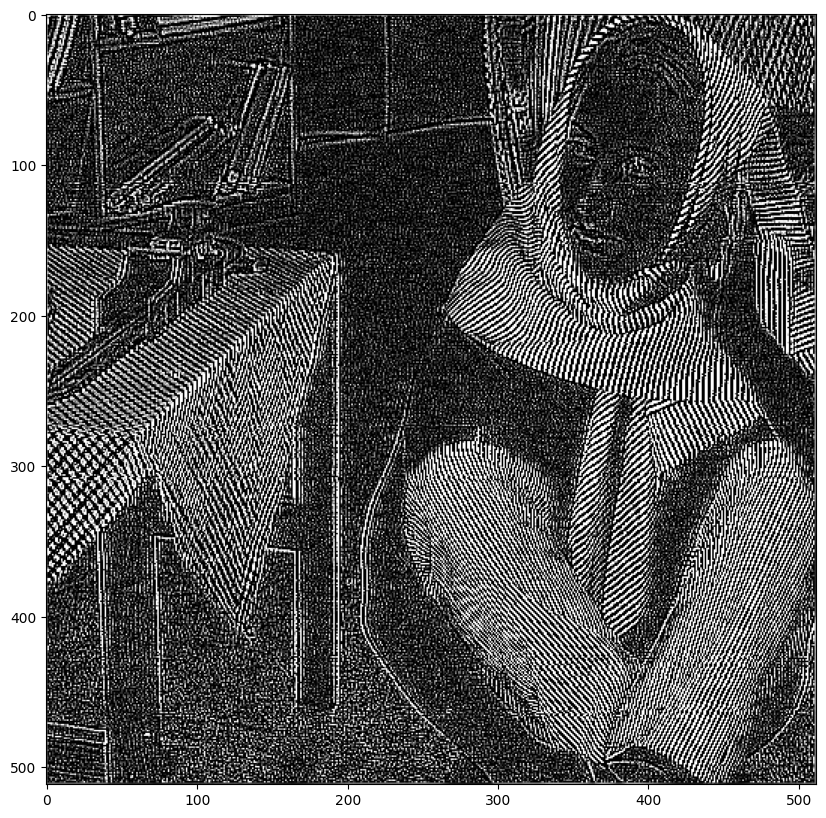

In [17]:
# Áp dụng bộ lọc phát hiện cạnh
img_gray = img_gray.filter(ImageFilter.FIND_EDGES)
# Hiển thị ảnh kết quả (các cạnh được tìm thấy)
plt.figure(figsize=(10,10))
plt.imshow(img_gray, cmap='gray')


## Median

Median filters find the median of all the pixels under the kernel area and the central element is replaced with this median value. 


We can apply median filters to regular images but let’s see how we can use a median filter to improve segmentation. Consider the cameraman example: 


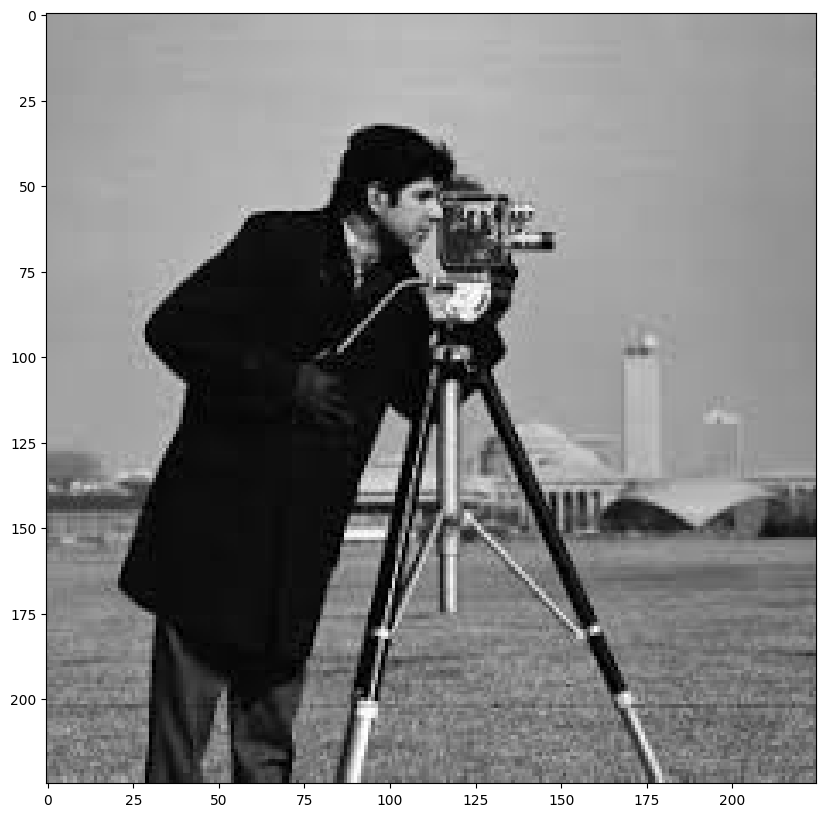

In [18]:
# Load the camera man image
image = Image.open("cameraman.jpeg")
# Make the image larger when it renders
plt.figure(figsize=(10,10))
# Renders the image
plt.imshow(image,cmap="gray")

Median filtering blurs the background, increasing the segmentation between the cameraman and the background


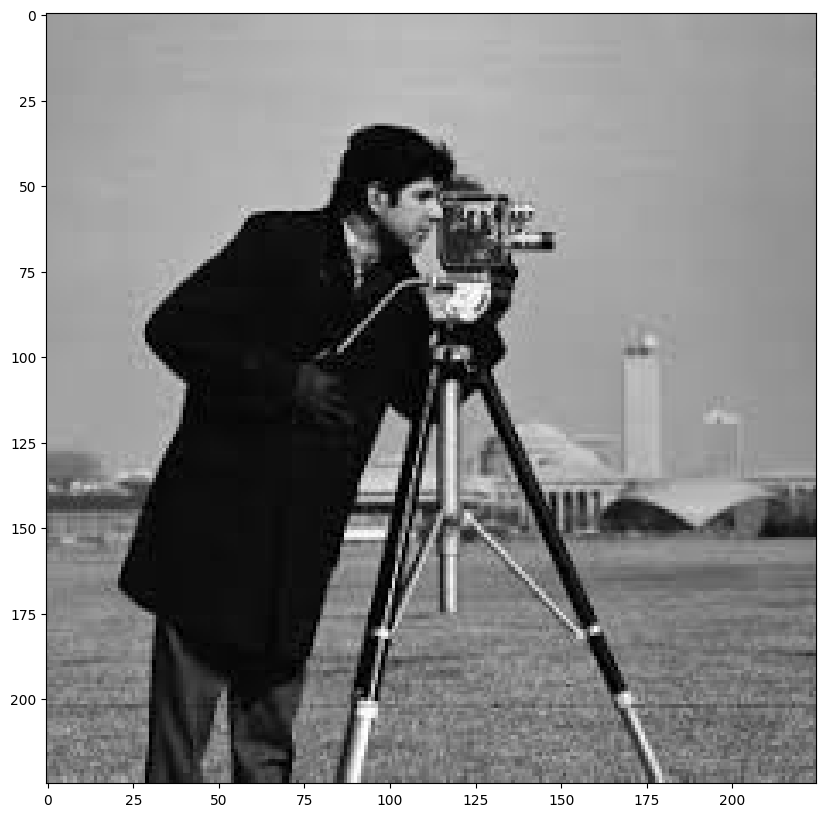

In [19]:
# Tải ảnh 'cameraman.jpeg'
image = Image.open("cameraman.jpeg")
# Hiển thị ảnh với kích thước lớn hơn
plt.figure(figsize=(10,10))
plt.imshow(image, cmap="gray")

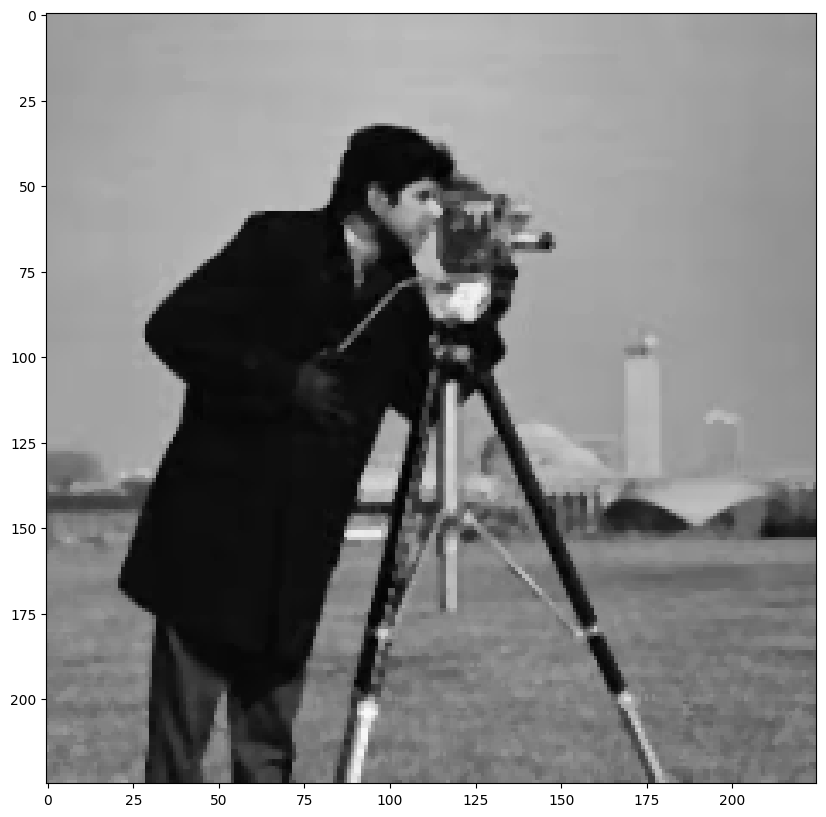

In [20]:
# Áp dụng bộ lọc trung vị (Median Filter) để giảm nhiễu
image = image.filter(ImageFilter.MedianFilter)
# Hiển thị ảnh đã lọc
plt.figure(figsize=(10,10))
plt.imshow(image, cmap="gray")

# References


[1]  Images were taken from: [https://homepages.cae.wisc.edu/~ece533/images/](https://homepages.cae.wisc.edu/~ece533/images/?utm_email=Email&utm_source=Nurture&utm_content=000026UJ&utm_term=10006555&utm_campaign=PLACEHOLDER&utm_id=SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-CV0101EN-Coursera-25797139)

[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.
